Our expectation with the original LEMBAS is as follows:
1) It cannot handle multiple cell types
2) It cannot account for the dispersion within a cluster at single-cell resolution, and will output the centroid of a cluster instead.

Next, we want to see whether scLEMBAS can capture single-cell resolution data.

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist, pdist, squareform

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import parse_network, io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainCat, TrainSC
from scLEMBAS.plotting import plot_embedding
from scLEMBAS.preprocess import embed_tf_activity

<Figure size 100x100 with 0 Axes>

In [2]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
if not os.path.isdir(models_path):
    os.mkdir(models_path)

In [3]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))

# Load and Parse Input Signaling Network

In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [5]:
sn_ppis = parse_network.load_network('omnipath', organism = 'mouse', static = True)

sn_ppis = parse_network.correct_network(sn_ppis = sn_ppis,
                                        source_label = source_label, target_label = target_label,
                                        stimulation_label = stimulation_label, inhibition_label = inhibition_label)

sn_ppis = parse_network.extract_network(sn_ppis, curation_effort_thresh = 5, n_references_thresh = 3,
                                        resources = ['HuRI','IntAct','KEGG-MEDICUS','NetPath','Reactome_SignaLink3','SPIKE','SignaLink3','SIGNOR', 
                                                'Baccin2019', 'Ramilowski2015', 'Reactome_LRdb', 'UniProt_LRdb', 'CellChatDB', 'CellPhoneDB', 'connectomeDB2020', 'scConnect'], 
                                        source_label = source_label, target_label = target_label,
                                        drop_self = True, verbose = True)



The thresholds filtered 66381  of 75185 interactions
The resources filtered 1940  of 8804 interactions


Filter for nodes that fall in paths between ligands and receptors (fully connected network):

In [6]:
tf_labels = tf_adata.var.index.unique().tolist()

ligand_labels = tf_adata.obs['sample'].unique().tolist()
ligand_labels = [(l[0] + l[1:].lower()).replace('-', '') for l in ligand_labels] # mouse naming convention

# filter for paths b/w ligand and tf
fn_1, _ = parse_network.create_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'shortest')
fn_2, _ = parse_network.create_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'connected')
# of the methods to identify paths, retain the one that has the most interactions
if fn_1.shape[0] > fn_2.shape[0]:
    sn_ppis = fn_1
else:
    sn_ppis = fn_2

del fn_1, fn_2

100%|████████████████████████████████████| 8432/8432 [00:00<00:00, 22771.06it/s]


Finally, let's format the network as needed for input to building the model:

In [7]:
sn_ppis = parse_network.format_network(sn_ppis, weight_label, stimulation_label, inhibition_label) 
# sn_ppis.to_csv(os.path.join(data_path, 'processed', 'ID_input_network.csv'))

In [8]:
print('The signaling network contains {} interactions'.format(sn_ppis.shape[0]))
sn_ppis[[source_label, target_label, weight_label, stimulation_label, inhibition_label]].head()

The signaling network contains 4583 interactions


,source_genesymbol,target_genesymbol,mode_of_action,consensus_stimulation,consensus_inhibition
145,Mapk14,Mapkapk2,1.0,True,False
146,Mapkapk2,Mapk14,0.1,False,False
152,Epor,Jak2,0.1,False,False
153,Jak2,Epor,1.0,True,False
159,Numb,Notch1,-1.0,False,True


The interactions include the following input ligands:

In [9]:
all_nodes = sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()
input_ligands_available = sorted(set(ligand_labels).intersection(all_nodes))
print(*input_ligands_available, sep = ', ')

Egf, Gdnf, Hgf, Ifng, Il10, Il11, Il13, Il15, Il1a, Il1b, Il2, Il21, Il4, Il5, Il6, Il7, Il9, Lif, Osm, Tslp


# Explore performance on TF activity

In [10]:
group_label = 'TF_clusters' # ordered cateogry in obs

## Scenario 3:

In [11]:
model_no = 3

The simplest scenario is:
- 2 cell type
- 1 ligand
- Binary ligand exposure (0 or 1)
- Exposure leads to distinct clusters in TF activity space

For now, we simply use visualization to identify the most distinct clusters:

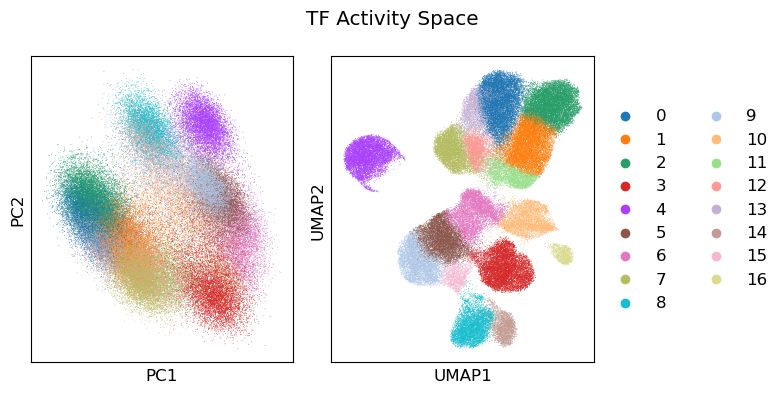

In [12]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(tf_adata, color='TF_clusters', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(tf_adata, color='TF_clusters', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('TF Activity Space')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

Based on these results, we choose clusters 2, 3, 4, and 5:

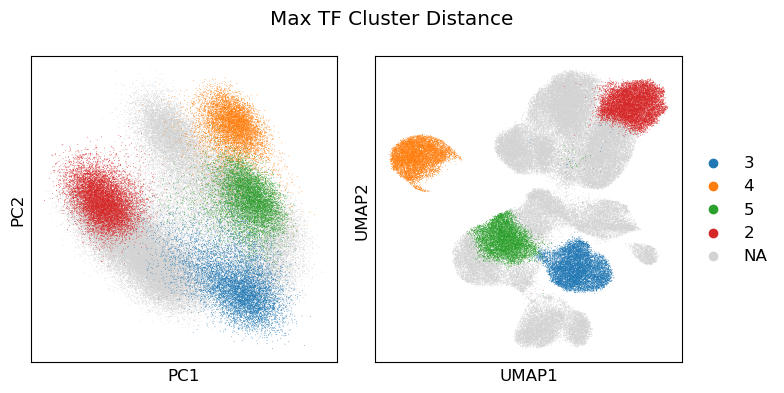

In [13]:
max_clusters = ['3', '4', '5', '2']
viz_adata = tf_adata.copy()
viz_adata.obs[group_label + '_color'] = pd.Categorical(viz_adata.obs[group_label], 
                                                       categories = max_clusters, 
                                                       ordered = True)
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(viz_adata, color=group_label + '_color', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(viz_adata, color=group_label + '_color', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('Max TF Cluster Distance')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

Based on these results, let's say that cluster 9 is unstimulated, and cluster 15 is stimulated. 

In [12]:
max_clusters = ['3', '4', '5', '2']

In [13]:
np.random.seed(seed)
selected_ligand = np.random.choice(input_ligands_available, 1)[0]
print('The selected ligand is: ' + selected_ligand)

subset_tf = tf_adata[tf_adata.obs.TF_clusters.isin(max_clusters)]
subset_tf.obs.TF_clusters.value_counts()

The selected ligand is: Il5


TF_clusters
2    9687
3    8522
4    7336
5    6970
Name: count, dtype: int64

For now, for speed, let's subset so that there are a smaller number of "samples" per condition:

In [14]:
sample_size = int(2.5e3)

barcodes = []
for cluster_label in subset_tf.obs.TF_clusters.unique():
    bc = subset_tf.obs[subset_tf.obs.TF_clusters == cluster_label].index
    np.random.seed(seed)
    barcodes += list(np.random.choice(bc, sample_size, replace = False))
subset_tf = subset_tf[barcodes, :]
subset_tf.obs.TF_clusters.value_counts()

TF_clusters
2    2500
3    2500
4    2500
5    2500
Name: count, dtype: int64

Next, let's initialize the model. 

Let's say clusters 4 and 5 are unstimulated, and 3 and 2 are stimulated
We assign clusters 3 and 4 as cell Type A, and 5 and 2 as cell type B.

In [15]:
ligand_input = pd.DataFrame(subset_tf.obs.TF_clusters.map({'4': 0, '5': 0, '3': 1, '2': 1}))
ligand_input.columns = [selected_ligand]


covariates = pd.DataFrame(subset_tf.obs.TF_clusters.map({'3': 'A', '4': 'A',
                                                        '5': 'B', '2': 'B'}))
covariates.columns = ['celltype']


tf_output = pd.DataFrame(subset_tf.X, index = subset_tf.obs.index, columns = subset_tf.var.index)

In [16]:
subset_tf.obs = pd.concat([covariates, ligand_input, pd.DataFrame({'TF_clusters': subset_tf.obs.TF_clusters})], axis = 1)

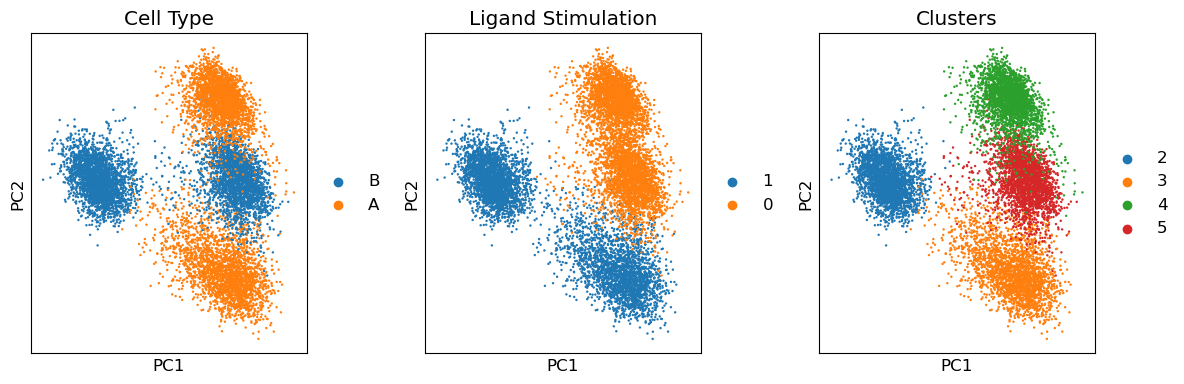

In [17]:
viz_adata = subset_tf.copy()
for col in viz_adata.obs.columns:
    viz_adata.obs[col] = pd.Categorical(viz_adata.obs[col],
                                        categories = viz_adata.obs[col].unique())


fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))
sc.pl.pca(viz_adata, color='celltype', ax = ax[0], show = False)
ax[0].set_title('Cell Type')

sc.pl.pca(viz_adata, color=selected_ligand, ax = ax[1], show = False)
ax[1].set_title('Ligand Stimulation')

sc.pl.pca(viz_adata, color='TF_clusters', ax = ax[2], show = False)
ax[2].set_title('Clusters')


fig.tight_layout()
plt.show()

In [18]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 

# training parameters
lr_params = {'max_epochs': 5000, 'maximum_learning_rate': 2e-3, 'minimum_learning_rate': 2e-4,
                 'lr_restart_epoch': 1000, 'reset_optimizer_epoch': 200, 
                'lr_decay': 0.9, 'lr_restart_factor': 1, 'warmup_epochs': 500}

other_params = {'train_batch_size': 512, 'test_batch_size': 512, 'validation_batch_size': 512, 
                    'network_noise_scale': 10, 'gradient_noise_scale': 1e-9}

regularization_params = {'input_lambda_L2': 1e-6, 'hidden_state_lambda_L2': 1e-6, 'bias_lambda_L2': 1e-6, 
                             'output_lambda_L2': 1e-6, 
                         'discriminator_lambda_L2': 1e-5,
                         'moa_lambda_L1': 0.1, #'ligand_lambda_L2': 1e-5, 
                         'uniform_lambda_L2': 1e-4,  
                         'uniform_max': (1/1.2), 
                         'spectral_loss_factor': 1e-5}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.ReLU,
              'vae_n_hidden_nodes': [1024, 768, 512], 
              'vae_var_min': 1e-4}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}
target_spectral_radius = 0.8

In [19]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     expr = subset_tf.to_df(), 
                     covariates = subset_tf.obs,
                     categorical_covariate_keys = ['celltype'],
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

In [20]:
discriminator_params = {'batch_momentum': 0.01,
                        'layer_norm': False,
                        'dropout_rate': 0.1,
                        'activation_fn': torch.nn.modules.activation.ReLU,
                        'n_hidden_nodes': [16, 16, 16]}

# Start dev

In [21]:
self = mod

In [22]:
trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                   discriminator_optimizer = torch.optim.Adam,
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True,
                   track_validation = False)

In [26]:
from scLEMBAS.model.train import *

In [28]:
self = trainer

In [31]:
start_time = time.time()
e = 0
cur_lr = self.prediction_optimizer.param_groups[0]['lr']

# set learning rate
#             cur_lr = utils.get_lr(e, self.hyper_params['max_epochs'], max_height = self.hyper_params['maximum_learning_rate'],
#                                 start_height=self.hyper_params['minimum_learning_rate'], end_height=1e-6, peak = self.hyper_params['lr_restart_epoch'])
self.prediction_optimizer.param_groups[0]['lr'] = cur_lr
#     raise ValueError('Need to change the discriminator optimizer with lr scheduler')
self.discriminator_optimizer.param_groups[0]['lr'] = cur_lr

cur_loss = []
cur_eig = []
cur_loss_with_reg = []
cur_pearson = []


# iterate through batches
if self.mod.seed:
    utils.set_seeds(self.mod.seed + e)
for batch, (X_in_, y_out_, covariates_idx_, expr_) in enumerate(self.train_dataloader):
    break

In [37]:
expr_.shape

torch.Size([512, 687])

In [157]:
# trainer = TrainSC(mod = mod,
#                    prediction_optimizer = torch.optim.Adam,
#                    prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
#                    discriminator_optimizer = torch.optim.Adam,
#                   discriminator_params = discriminator_params,
#                    hyper_params = training_params,
#                    train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
#                    train_seed = seed, 
#                    track_test = True,
#                    track_validation = False)

sc_mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     expr = subset_tf.to_df(), 
                     covariates = subset_tf.obs,
                     categorical_covariate_keys = ['celltype'],
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     expr = None, #subset_tf.to_df(), 
                     covariates = subset_tf.obs,
                     categorical_covariate_keys = ['celltype'],
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)
self = TrainCat(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True, 
                  track_validation = False)

In [153]:
from scLEMBAS.model.train import *

In [150]:
covariates_idx = None
expr = None

if include_covariates:
    covariates_idx = self.mod.signaling_network.covariates_to_tensor(sample_ids = self.X_train.index)
if include_expr:
    
    
    
model_data = ModelData(X_in = self.mod.df_to_tensor(self.X_train).to('cpu'), 
                   y_out = self.mod.df_to_tensor(self.y_train).to('cpu'),
                   covariates_idx = covariates_idx)

,Il5
CTTCAATGTCAGGTGA-04,1
CCTAAGACAGCCATTA-10,0
CTATCTACATGGACAG-32,0
AGGTAGGGTAGCTTGT-10,0
ACTGTCCGTAGCCCTG-29,1
...,...
ATCTTCATCAGGTGTT-09,1
TCGCTCACACAGTCAT-06,0
AGAAGCGAGCGGTAGT-08,0
GTAGGTTAGCCTCATA-39,0


In [166]:
expr

tensor([[0.5539, 0.3620, 0.6908,  ..., 0.8218, 0.6416, 0.5486],
        [0.5335, 0.3413, 0.6040,  ..., 0.7604, 0.3019, 0.2542],
        [0.7699, 0.4175, 0.4095,  ..., 0.6188, 0.4281, 0.5439],
        ...,
        [0.2989, 0.3330, 0.6017,  ..., 0.4882, 0.1600, 0.2581],
        [0.4685, 0.3112, 0.3616,  ..., 0.7662, 0.3534, 0.5214],
        [0.4578, 0.4408, 0.5129,  ..., 0.4906, 0.4170, 0.5149]],
       device='cuda:0')

In [165]:
expr = self.mod.df_to_tensor(sc_mod.expr.loc[self.X_train.index,:])

In [170]:
mod

SignalingModel(
  (input_layer): ProjectInput()
  (signaling_network): BioNetCat(
    (cat_embeddings): ModuleDict(
      (celltype): Embedding(2, 1331, max_norm=1)
    )
  )
  (output_layer): ProjectOutput()
)

In [173]:
self = TrainBase(mod = sc_mod,
                 prediction_optimizer = torch.optim.Adam,
                 prediction_loss_fn = torch.nn.MSELoss(reduction='mean'))

In [175]:
include_covariates = True
include_expr = True

In [176]:
covariates_idx = None
expr = None

if include_covariates:
    covariates_idx = self.mod.signaling_network.covariates_to_tensor(sample_ids = self.X_train.index)
if include_expr:
    expr = self.mod.df_to_tensor(self.mod.expr.loc[self.X_train.index, :])

In [179]:
self.mod.X_in.shape

(10000, 1)

In [178]:
expr.shape

torch.Size([8000, 687])

In [ ]:
covariates_idx = None
expr = None

if include_covariates:
    covariates_idx = self.mod.signaling_network.covariates_to_tensor(sample_ids = self.X_train.index)
if include_expr:
    expr = self.mod.df_to_tensor(self.mod.expr.loc[self.X_train.index, :])
model_data = ModelData(X_in = self.mod.df_to_tensor(self.X_train).to('cpu'), 
                   y_out = self.mod.df_to_tensor(self.y_train).to('cpu'),
                       expr = expr,
                   covariates_idx = covariates_idx)

In [188]:
class ModelData(Dataset):
    def __init__(self, 
                 X_in: torch.tensor, 
                 y_out: torch.tensor, 
                 covariates_idx: Optional[torch.tensor] = None, 
                expr: Optional[torch.tensor] = None):
            """_summary_

            Parameters
            ----------
            X_in : torch.tensor
                _description_
            y_out : torch.tensor
                _description_
            covariates_idx : Optional[torch.tensor], optional
                the numerical index representation of the categorical covariates for each sample, by default None
                can be obtained from `mod.signaling_network.covariates_idx`
            expr : torch.tensor
                the gene expression matrix, can be obtained from mod.expr
            """
            self.X_in = X_in
            self.y_out = y_out
    #         if self.covariates is not None:
    #             self.covariates = covariates
    #         else:
    #             self.covariates = torch.full(X_train.shape, torch.nan)
            if covariates_idx is not None:
                self.covariates_idx = covariates_idx
            else:
                self.covariates_idx = torch.full(self.X_in.shape, torch.nan, device='cpu')
                
            if expr is not None:
                self.expr = expr
            else:
                self.expr = torch.full(self.X_in.shape, torch.nan, device='cpu')

    def __len__(self) -> int:
        "Returns the total number of samples."
        return self.X_in.shape[0]
    def __getitem__(self, idx: int):
        "Returns one sample of data, data and label (X, y)."
        return self.X_in[idx, :], self.y_out[idx, :], self.covariates_idx[idx,:], self.expr[idx,:]

In [192]:
self.__dict__.keys()

dict_keys(['hyper_params', 'mod', 'prediction_loss_fn', 'prediction_optimizer', 'lr_scheduler', 'reset_state', 'track_test', 'track_validation', 'train_seed', 'X_train', 'X_test', 'X_val', 'y_train', 'y_test', 'y_val', 'stats_df'])

In [196]:
self.track_test = True

In [ ]:
covariates_idx = None
expr = None

if include_covariates:
    covariates_idx = self.mod.signaling_network.covariates_to_tensor(sample_ids = self.X_train.index)
if include_expr:
    expr = self.mod.df_to_tensor(self.mod.expr.loc[self.X_train.index, :])
model_data = ModelData(X_in = self.mod.df_to_tensor(self.X_train).to('cpu'), 
                   y_out = self.mod.df_to_tensor(self.y_train).to('cpu'),
                       expr = expr,
                   covariates_idx = covariates_idx)
self.train_dataloader = DataLoader(dataset=model_data,
                                   batch_size=self.hyper_params['train_batch_size'],
                                   drop_last = False,
                                   pin_memory = False,#pin_memory,
                                   shuffle=True) 
if self.track_test:
    if include_covariates:
        covariates_idx = self.mod.signaling_network.covariates_to_tensor(sample_ids = self.X_test.index)
    model_data = ModelData(X_in = self.mod.df_to_tensor(self.X_test).to('cpu'), 
                       y_out = self.mod.df_to_tensor(self.y_test).to('cpu'),
                       covariates_idx = covariates_idx)
    self.test_dataloader = DataLoader(dataset=model_data,
                                       batch_size=self.hyper_params['test_batch_size'],
                                       drop_last = False,
                                       pin_memory = False,#pin_memory,
                                       shuffle=False)
if self.track_validation:
    if include_covariates:
        covariates_idx = self.mod.signaling_network.covariates_to_tensor(sample_ids = self.X_val.index)
    model_data = ModelData(X_in = self.mod.df_to_tensor(self.X_val).to('cpu'), 
                       y_out = self.mod.df_to_tensor(self.y_val).to('cpu'),
                       covariates_idx = covariates_idx)
    self.validation_dataloader = DataLoader(dataset=model_data,
                                       batch_size=self.hyper_params['validation_batch_size'],
                                       drop_last = False,
                                       pin_memory = False,#pin_memory,
                                       shuffle=False)

In [ ]:
class TrainBase:
    """Base class for training the signaling model."""

    LR_PARAMS = {'max_epochs': 5000, 'maximum_learning_rate': 2e-3, 'minimum_learning_rate': 2e-4,
                 'lr_restart_epoch': 1000, 'reset_optimizer_epoch': 200, 
                'lr_decay': 0.9, 'lr_restart_factor': 1, 'warmup_epochs': 500}
    OTHER_PARAMS = {'train_batch_size': 512, 'test_batch_size': 512, 'validation_batch_size': 512, 
                    'network_noise_scale': 10, 'gradient_noise_scale': 1e-9}
    REGULARIZATION_PARAMS = {'input_lambda_L2': 1e-6, 'hidden_state_lambda_L2': 1e-6, 'bias_lambda_L2': 1e-6, 
                             'output_lambda_L2': 1e-6,
                             'moa_lambda_L1': 0.1, #'ligand_lambda_L2': 1e-5, 
                            'uniform_lambda_L2': 1e-4, 'uniform_min': 0, 'uniform_max': (1/1.2), 'spectral_loss_factor': 1e-5}
    SPECTRAL_RADIUS_PARAMS = {'n_probes_spectral': 5, 'power_steps_spectral': 50, 'subset_n_spectral': 10}
    HYPER_PARAMS = {**LR_PARAMS, **OTHER_PARAMS, **REGULARIZATION_PARAMS, **SPECTRAL_RADIUS_PARAMS}

    def __init__(self, 
                 mod, 
                 prediction_optimizer: torch.optim, 
                 prediction_loss_fn: torch.nn.modules.loss,
                 hyper_params: Dict[str, Union[int, float]] = None,
                 # train_samples: Optional[List[str]] = None, 
                 train_split: Optional[Dict[str, Union[float, List[str]]]] = {'train': 0.8, 'test': 0.2, 'validation': None},
                 train_seed: int = None, 
                 track_test: bool = False,
                 track_validation: bool = False
                ):

In [ ]:
(self,
                 mod, 
                 prediction_optimizer: torch.optim, 
                 prediction_loss_fn: torch.nn.modules.loss,
                 discriminator_optimizer: torch.optim,
                 discriminator_params: Dict = CatDiscriminator.DEFAULT_HYPER_PARAMS,
                 hyper_params: Dict[str, Union[int, float]] = None,
                 train_split: Optional[Dict[str, Union[float, List[str]]]] = {'train': 0.8, 'test': 0.2, 'validation': None},
                 train_seed: int = None,
                 track_test: bool = False,
                 track_validation: bool = False
                 ):

In [141]:
from scLEMBAS.model.model_components import *

In [142]:
CatDiscriminator.DEFAULT_HYPER_PARAMS

{'batch_momentum': 0.01,
 'layer_norm': False,
 'dropout_rate': 0.1,
 'activation_fn': torch.nn.modules.activation.ReLU,
 'n_hidden_nodes': [16, 16, 16]}

In [22]:
X_in = self.df_to_tensor(self.X_in)
y_out = self.df_to_tensor(self.y_out)
expr = self.df_to_tensor(self.expr)
covariates_idx = self.signaling_network.covariates_to_tensor(sample_ids = self.X_in.index)

In [23]:
Y_hat, Y_full, bias_global = mod(X_in, covariates_idx, expr)

# end

Next, let's train the model:

In [ ]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainCat(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True, 
                  track_validation = False)
mod, cur_loss, cur_eig, stats_df = trainer.train_model(verbose = True)

  0%|                                                                   | 1/5000 [00:03<4:50:55,  3.49s/it]

i=0, l(tr)=1.34464, l(te)=1.32009, s=0.80157, r=0.00020, v=0.00000


  1%|▋                                                                 | 51/5000 [03:57<7:26:45,  5.42s/it]

i=50, l(tr)=0.73887, l(te)=0.73047, s=0.91079, r=0.00176, v=1.00000


  2%|█▎                                                               | 101/5000 [09:46<6:48:15,  5.00s/it]

...

  9%|█████▊                                                           | 451/5000 [39:03<6:21:15,  5.03s/it]

i=450, l(tr)=0.41842, l(te)=0.42089, s=0.92970, r=0.00021, v=186.00000


 10%|██████▌                                                          | 501/5000 [43:15<6:18:32,  5.05s/it]

i=500, l(tr)=0.41812, l(te)=0.42085, s=0.93191, r=0.00031, v=164.00000


 11%|███████                                                          | 547/5000 [47:06<6:12:28,  5.02s/it]

In [22]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainCat(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True, 
                  track_validation = False)
mod, cur_loss, cur_eig, stats_df = trainer.train_model(verbose = True)

# store results
io.write_pickled_object(stats, os.path.join(models_path, 'model_' + str(model_no) + '_training_stats.pickle'))
torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))
stats_df.to_csv(os.path.join(models_path, 'model_' + str(model_no) + '_training_stats.csv'))
for df_type in ['X_train', 'X_test', 'X_val', 'y_train', 'y_test', 'y_val']:
    trainer.__dict__[df_type].to_csv(os.path.join(models_path, 'model_' + str(model_no) + '_' + df_type + '.csv'))

# Start

In [3]:
os.listdir(models_path)

['model_0_state_dict.pth',
 'model_1_state_dict.pth',
 'model_1_X_test.csv',
 'model_0_datamodule.pickle',
 'model_1_training_stats.pickle',
 'model_2_X_test.csv',
 'model_1_y_train.csv',
 'model_1_y_test.csv',
 'model_2_training_stats.pickle',
 'model_2_y_train.csv',
 'model_1_X_train.csv',
 'model_2_y_test.csv',
 'model_2_state_dict.pth',
 'model_2_X_train.csv']

In [113]:
stats = io.read_pickled_object(os.path.join(models_path, 'model_2_training_stats.pickle'))

<Axes: xlabel='epoch', ylabel='learning_rate'>

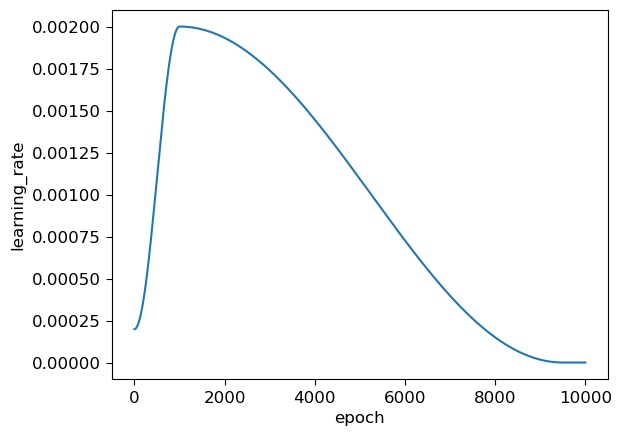

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': stats['learning_rate']})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

In [106]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 

# training parameters
lr_params = {'max_epochs': 5000, 'maximum_learning_rate': 2e-3, 'minimum_learning_rate': 2e-4,
                 'lr_restart_epoch': 1000, 'reset_optimizer_epoch': 200}

other_params = {'batch_size': 256, 
                'network_noise_scale': 10, 
                'gradient_noise_scale': 1e-9}

regularization_params = {'param_lambda_L2': 1e-6, 
                         'discriminator_lambda_L2': 1e-5,
                         'moa_lambda_L1': 0.1, #'ligand_lambda_L2': 1e-5, 
                         'uniform_lambda_L2': 1e-4,  
                         'uniform_max': (1/1.2), 
                         'spectral_loss_factor': 1e-5}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}
target_spectral_radius = 0.8

mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     covariates = subset_tf.obs,
                     categorical_covariate_keys = ['celltype'],
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainCat(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True, 
                  track_validation = False)

In [93]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import pytorch_warmup as warmup

In [107]:
warmup_epochs = 500
self = trainer

In [108]:
prediction_optimizer = torch.optim.Adam

In [118]:
self.prediction_optimizer = prediction_optimizer(self.mod.parameters(), 
                                                 lr=self.hyper_params['minimum_learning_rate'], 
                                                 weight_decay=0)

In [119]:
# warmup_scheduler = warmup.ExponentialWarmup(optimizer = self.prediction_optimizer, warmup_period=warmup_epochs)
# lr_scheduler = CosineAnnealingWarmRestarts(optimizer = self.prediction_optimizer,
#                                            T_0 = self.hyper_params['lr_restart_epoch'],
#                                            eta_min = self.hyper_params['minimum_learning_rate'], 
#                                            last_epoch = -1)

In [120]:
lr_scheduler = ChainedScheduler(optimizer = self.prediction_optimizer,
                                                              T_0 = self.hyper_params['lr_restart_epoch'],
                                                              T_mul = 1, 
                                                              gamma = 1,
                                                              eta_min = self.hyper_params['minimum_learning_rate'],
                                                              max_lr=self.hyper_params['maximum_learning_rate'],
                                                              warmup_steps = 500,
                                                              last_epoch = -1)

In [121]:
# learning_rates = []
# for epoch in range(self.hyper_params['max_epochs']):
#     cur_lr = self.prediction_optimizer.param_groups[0]['lr']
#     learning_rates.append(cur_lr)
    
#     self.prediction_optimizer.step()
#     with warmup_scheduler.dampening():
#         lr_scheduler.step()    
learning_rates = []
lr_2 = []
for epoch in range(self.hyper_params['max_epochs']):
    self.prediction_optimizer.step()
    lr_scheduler.step()
    lr = lr_scheduler.get_lr()[0]
    self.prediction_optimizer.param_groups
    learning_rates.append(lr)
    lr_2.append(self.prediction_optimizer.param_groups[0]['lr'])

In [102]:
np.allclose(learning_rates, lr_2)

True

In [101]:
lr_2[:10]

[0.0002035928143712575,
 0.00020718562874251498,
 0.00021077844311377246,
 0.00021437125748502995,
 0.00021796407185628743,
 0.0002215568862275449,
 0.0002251497005988024,
 0.00022874251497005988,
 0.00023233532934131736,
 0.00023592814371257485]

<Axes: xlabel='epoch', ylabel='learning_rate'>

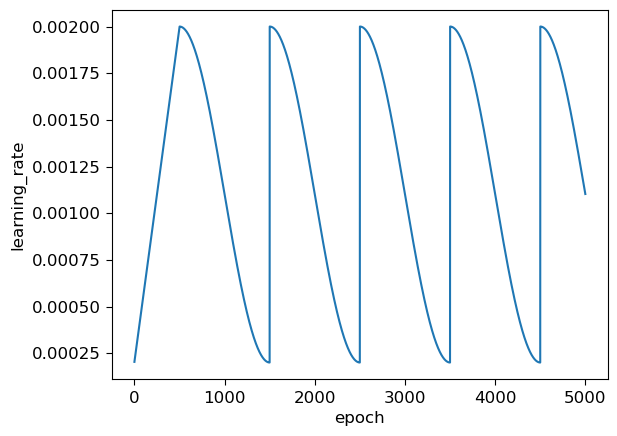

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

<Axes: xlabel='epoch', ylabel='learning_rate'>

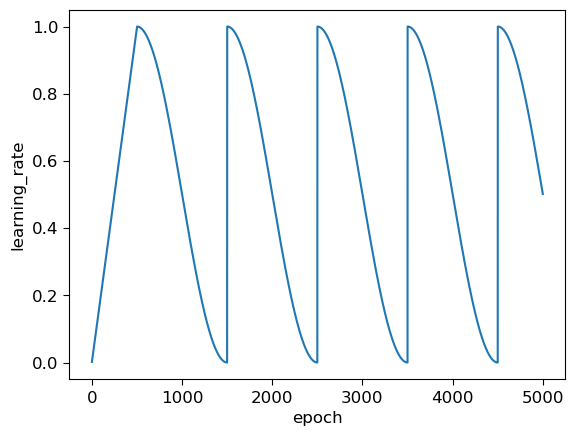

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

In [51]:
lr_scheduler = CosineAnnealingWarmRestarts(optimizer = self.prediction_optimizer,
                                           T_0 = self.hyper_params['lr_restart_epoch'],
                                           eta_min = self.hyper_params['minimum_learning_rate'], 
                                           last_epoch = -1)

In [52]:
learning_rates = []
for epoch in range(self.hyper_params['max_epochs']):
    self.prediction_optimizer.step()
    lr_scheduler.step()
    lr = lr_scheduler.get_lr()[0]
    learning_rates.append(lr)

<Axes: xlabel='epoch', ylabel='learning_rate'>

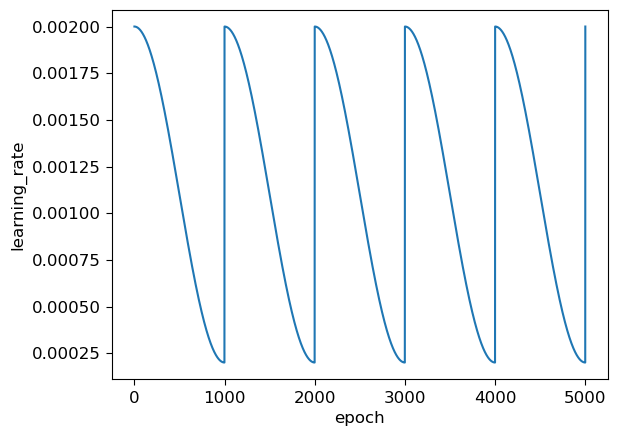

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

In [112]:
from lightning.

<Axes: xlabel='epoch', ylabel='learning_rate'>

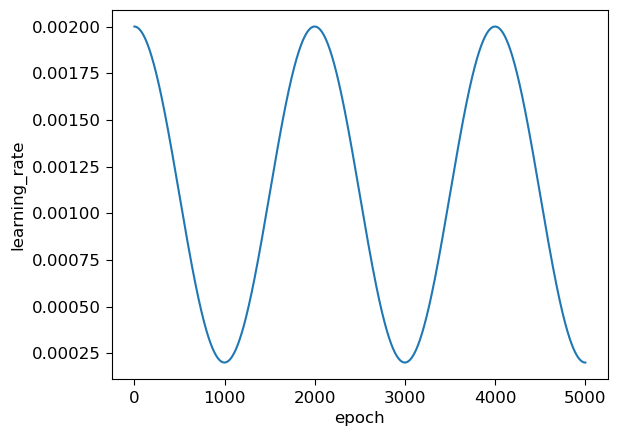

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

<Axes: xlabel='epoch', ylabel='learning_rate'>

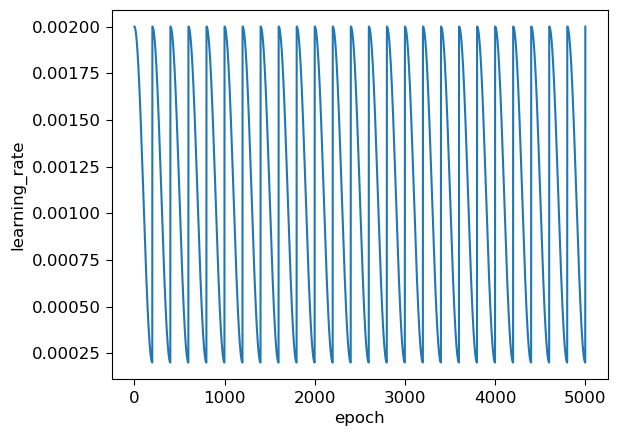

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

<Axes: xlabel='epoch', ylabel='learning_rate'>

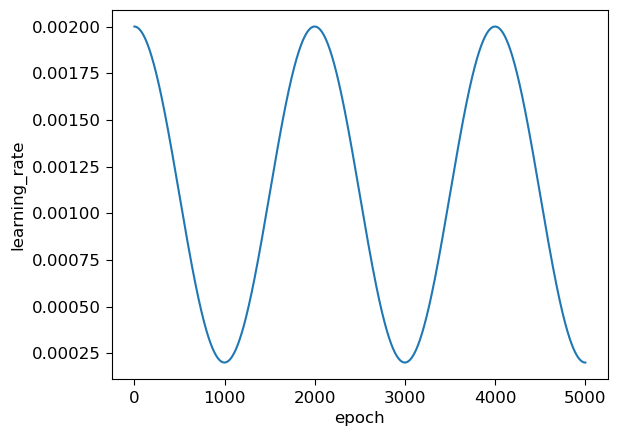

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

# End

Let's see what the output looks like:

In [ ]:
def unique_tol(arr, tol=1e-5, axis=0):
    if axis == 1:
        arr = arr.T
    norm_arr = arr / arr[:, [0]]
    
    # Sort the array based on rows
    sorted_indices = np.lexsort(norm_arr.T)
    sorted_arr = arr[sorted_indices, :]
    
    # Calculate the differences between consecutive rows
    diffs = np.diff(sorted_arr, axis=0)
    
    # Use a norm (e.g., L2 norm) to find row differences, then check against tolerance
    row_diffs = np.linalg.norm(diffs, axis=1)
    unique_row_indices = np.where(row_diffs > tol)[0]
    
    # Add the first row and the rows after significant changes
    unique_indices = np.r_[0, unique_row_indices + 1]
    
    # Select the unique rows
    unique_rows = sorted_arr[unique_indices, :]
    
    if axis == 1:
        unique_rows = unique_rows.T
        
    return unique_rows

We expect 4 unique predictions, one for each ligand/cell type combination:

In [ ]:
covariates_idx = mod.signaling_network.covariates_to_tensor(sample_ids = X_test.index)
X_test_tensor = mod.df_to_tensor(X_test)
y_pred, Y_full = mod(X_test_tensor, covariates_idx)
y_pred = y_pred.cpu().detach().numpy()

y_pred_unique = unique_tol(y_pred, tol = 1e-5, axis = 0)
print('The number of unique predictions across all test data is {}'.format(len(y_pred_unique)))

We can see that there are only 2 unique prediction values, because the model is currently not aware of single-cell resolution (or cell type) data. Let's see what exactly these predicted values are:

In [ ]:
ligand_input[selected_ligand] = pd.Categorical(ligand_input[selected_ligand], 
                                              categories = sorted(ligand_input[selected_ligand].unique()), 
                                              ordered = True)

# get the centroids in the full TF activity space
clf_full = NearestCentroid()
train_cats = subset_tf.obs.loc[y_train.index, ['celltype', selected_ligand]]
train_cats = train_cats.celltype.str.cat(train_cats[selected_ligand].astype(str), sep='_')
clf_full.fit(y_train, train_cats)
train_centroids = pd.DataFrame(clf_full.centroids_ , index = clf_full.classes_, columns = y_train.columns)

# get the predictions for stimulated (1) and unstimulated (0) b/w cell types A and B
test_preds = pd.DataFrame(index = train_centroids.index, columns = train_centroids.columns)
for ct in subset_tf.obs.celltype.unique():
    for ls in subset_tf.obs[selected_ligand].unique():
        cat_idx = subset_tf.obs[(subset_tf.obs.celltype == ct) & (subset_tf.obs[selected_ligand] == ls)].index
        cat_idx = cat_idx[cat_idx.isin(X_test.index)]
        # sample_id = cat_idx[0]
        covariates_idx = mod.signaling_network.covariates_to_tensor(cat_idx)
        X_test_ = mod.df_to_tensor(X_test.loc[cat_idx, :])
        y_pred, Y_full = mod(X_test_, covariates_idx)
        y_pred = unique_tol(y_pred.cpu().detach().numpy(), tol = 1e-5, axis = 0)
        
        test_preds.loc[ct + '_' + str(ls), :] = y_pred

# re-run the PCA on the training subset to visualize/project into this space
tf_adata_train = tf_adata[y_train.index, y_train.columns].copy()
tf_adata_train.obs.drop(columns = ['TF_clusters'], inplace = True)
tf_adata_train = embed_tf_activity(tf_adata_train, estimate_key = None, scanpy_pca = False)
tf_adata_train.TF_clusters = tf_adata[y_train.index, y_train.columns].obs.TF_clusters # replace with original clusters
pca = tf_adata_train.uns['pca']['pca_mod']

# get the train dataset centroids as well as project the predictions into pca space 
train_pca_centroids = pca.transform(train_centroids)
pred_pca_centroids = pca.transform(test_preds.values)

In [ ]:
viz_adata_ = viz_adata.copy()
viz_adata_ = viz_adata_[tf_adata_train.obs.index, ]
viz_adata_.obs['Condition'] = viz_adata_.obs.celltype.str.cat(viz_adata_.obs[selected_ligand].astype(str), sep='_')
train_cats = viz_adata_.obs.copy()

In [ ]:
w, h = 5,4
p1 = plot_embedding(adata = viz_adata_, group_label = 'Condition', embedding = 'pca', 
                    palette = 'Set2', width = w, height = h, size = 0.5)
p1 + p9.theme(figure_size=(w, h))

In [ ]:
# train_pc_rank = tf_adata_train.uns['pca']['pca_rank']
# y_train_eds_full = list()
# y_train_eds_reduced = list()
# for idx in y_train.index:
#     # full TF space
#     y_vals = y_train.loc[idx, :]
#     pred_type = train_cats.loc[idx, 'Condition']
#     y_centroid = train_centroids.loc[pred_type, :]

#     ed = np.linalg.norm(y_vals - y_centroid)
#     y_train_eds_full.append(ed)

#     # reduced space
#     y_vals = tf_adata_train.obsm['X_pca'][tf_adata_train.obs.index.tolist().index(idx),:][:train_pc_rank]
#     y_centroid = train_pca_centroids[train_centroids.index.tolist().index(pred_type), :][:train_pc_rank]

#     ed = np.linalg.norm(y_vals - y_centroid)
#     y_train_eds_reduced.append(ed)   
    
# fig, ax = plt.subplots(figsize = (12,3), ncols = 2)

# colors = sns.color_palette('Set1')

# sns.kdeplot(y_train_eds_full, ax = ax[0], color = colors[0])
# # children = plt.gca().get_children()
# l0 = ax[0].vlines(np.linalg.norm(y_pred_0 - train_centroids.loc[0,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[1])
# l1 = ax[0].vlines(np.linalg.norm(y_pred_1 - train_centroids.loc[1,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[2])
# ax[0].set_xlabel('Euclidean Distance to Training Centroid')
# ax[0].set_title('Full TF Activity Space')

# sns.kdeplot(y_train_eds_reduced, ax = ax[1], color = colors[0])
# children = plt.gca().get_children()
# l0 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[0,:train_pc_rank] - train_pca_centroids[0,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[1])
# l1 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[1,:train_pc_rank] - train_pca_centroids[1,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[2])
# ax[1].set_xlabel('Euclidean Distance to Training Centroid')
# ax[1].set_title('Reduced TF Activity Space ({} PCs)'.format(train_pc_rank))

# plt.legend([children[0], l0, l1], ['Training Data', 'Prediction: Unstimulated', 'Prediction: Stimulated'], 
#           bbox_to_anchor=(1, 1.05))
# fig.tight_layout()

In [ ]:
tf_adata_train.obs['Condition'] = viz_adata_.obs['Condition']

# training data
X_train = tf_adata_train.obsm['X_pca']
X_train = pd.DataFrame(tf_adata_train.obsm['X_pca'][:, :2], index = tf_adata_train.obs.index, 
                         columns = ['PC_' + str(i+1) for i in range(2)])
col_labels = [' '.join(i.split('_')) for i in X_train.columns]
X_train = pd.concat([X_train, tf_adata_train.obs.Condition], axis = 1)

In [ ]:
width, height = 5, 3
set1_colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#FFFF33', '#A65628']



tf_adata_train.obs['Condition'] = viz_adata_.obs['Condition']

# training data
X_train = tf_adata_train.obsm['X_pca']
X_train = pd.DataFrame(tf_adata_train.obsm['X_pca'][:, :2], index = tf_adata_train.obs.index, 
                         columns = ['PC_' + str(i+1) for i in range(2)])
col_labels = [' '.join(i.split('_')) for i in X_train.columns]
X_train = pd.concat([X_train, tf_adata_train.obs.Condition], axis = 1)

# centroids and predicted values
X_centroids = pd.DataFrame(train_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])
X_pred = pd.DataFrame(pred_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])

p3 = (
    p9.ggplot() +
    p9.geom_point(X_train, p9.aes(x=X_train.columns[0], y = X_train.columns[1], color = 'Condition'), 
                 size = 0.1) +
    p9.scale_color_manual(values=set1_colors) +
    p9.geom_point(X_centroids, p9.aes(x=X_centroids.columns[0], y = X_centroids.columns[1]), shape = 'X', color = 'black') +
    p9.geom_point(X_pred, p9.aes(x=X_pred.columns[0], y = X_pred.columns[1]), shape = '*', color = 'blue') +
    p9.xlab(col_labels[0]) + p9.ylab(col_labels[1]) + 
    p9.theme_bw() + p9.theme(figure_size=(width, height))  
    
)
p3